# **EDA Analysis**

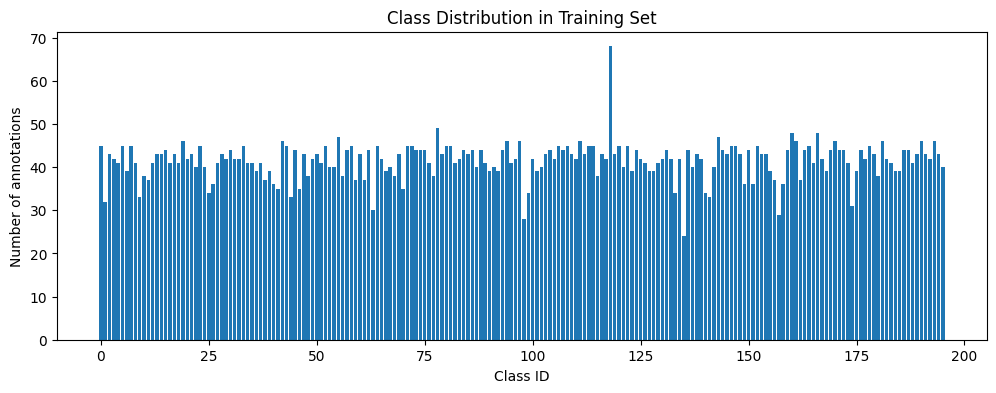

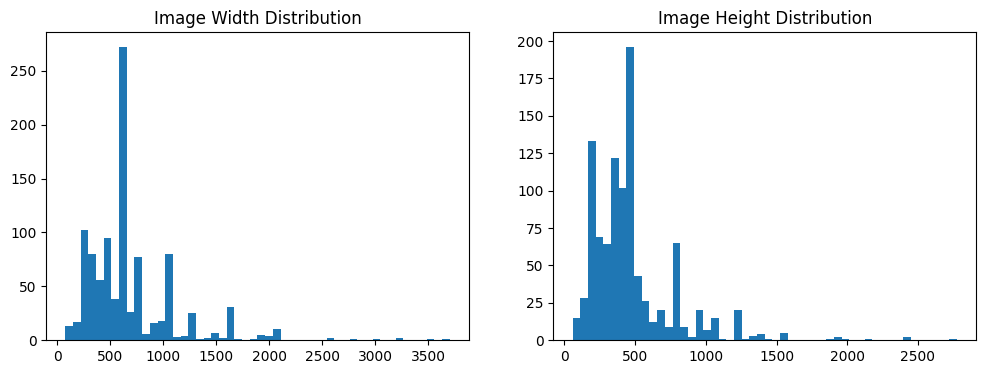

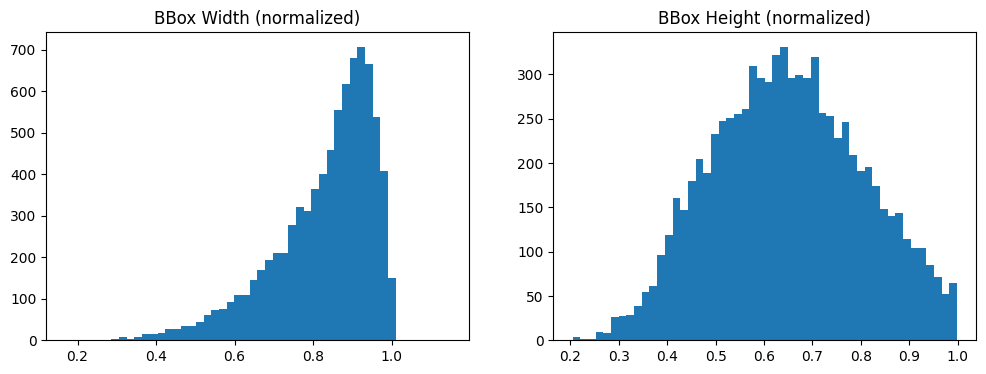

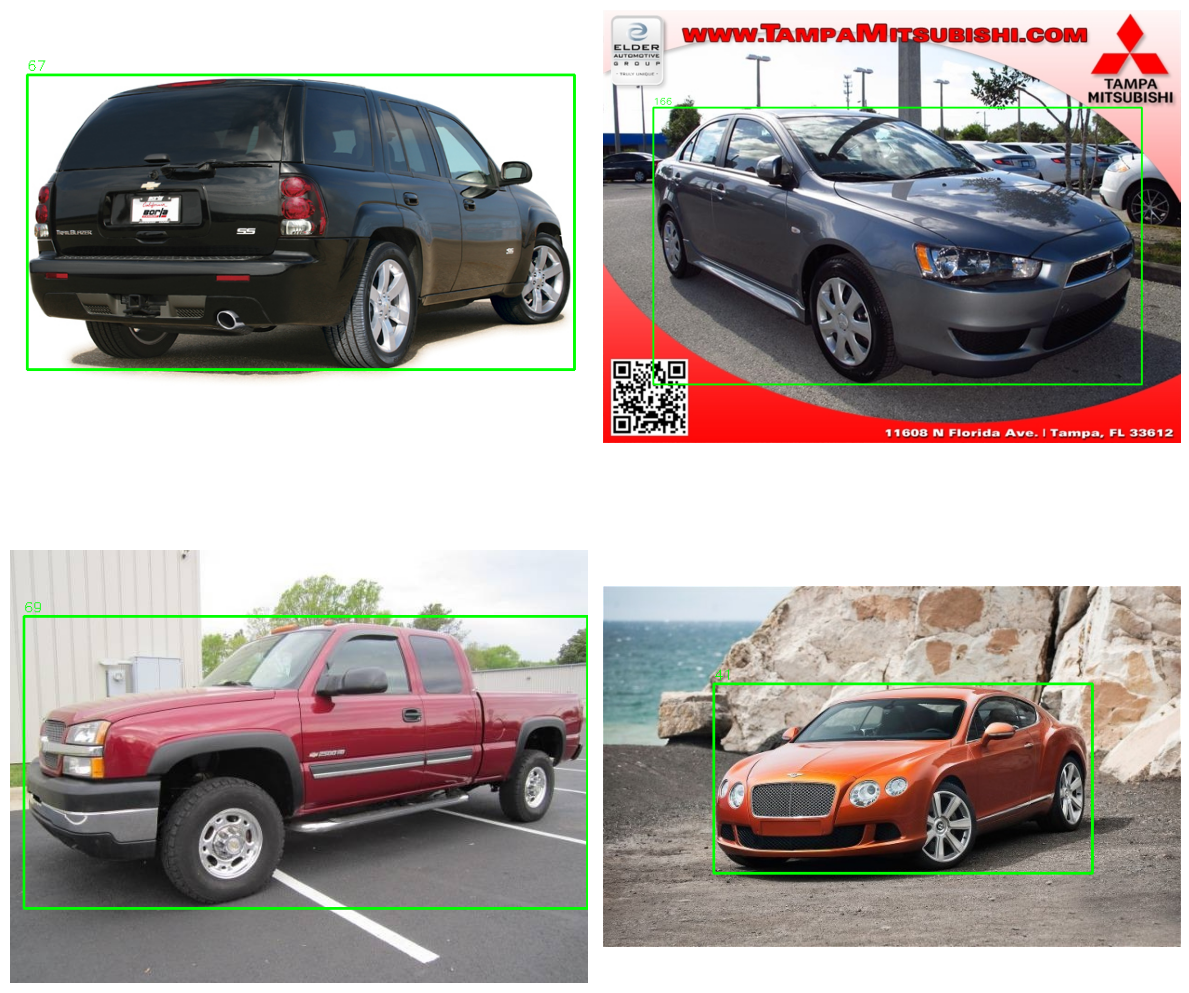

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
from glob import glob

label_dir = 'labels/train'
img_dir = 'images/train'

# helper: list only .txt labels and common image extensions
label_files = [p for p in glob(os.path.join(label_dir, '*.txt'))]
img_files = []
for ext in ('*.jpg','*.jpeg','*.png','*.bmp'):
    img_files.extend(glob(os.path.join(img_dir, ext)))
img_files = sorted(img_files)

# 1. 类别分布（更健壮）
class_ids = []
for lf in label_files:
    try:
        with open(lf, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) < 1:
                    continue
                try:
                    class_id = int(parts[0])
                    class_ids.append(class_id)
                except ValueError:
                    # 非法行，跳过并记录
                    print(f"Warning: bad class id in {lf}: {parts[0]}")
    except Exception as e:
        print(f"Warning: cannot read {lf}: {e}")

if class_ids:
    class_counts = Counter(class_ids)
    plt.figure(figsize=(12,4))
    plt.bar(list(class_counts.keys()), list(class_counts.values()))
    plt.xlabel('Class ID')
    plt.ylabel('Number of annotations')
    plt.title('Class Distribution in Training Set')
    plt.show()
else:
    print("No class ids found.")

# 2. 图像尺寸分布（抽样并跳过无法读取的图片）
sizes = []
sample_img_files = img_files[:1000]  # 抽样上限
for p in sample_img_files:
    img = cv2.imread(p)
    if img is None:
        print(f"Warning: cannot read image {p}")
        continue
    h, w = img.shape[:2]
    sizes.append((w, h))

if sizes:
    widths, heights = zip(*sizes)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.hist(widths, bins=50)
    plt.title('Image Width Distribution')
    plt.subplot(1,2,2)
    plt.hist(heights, bins=50)
    plt.title('Image Height Distribution')
    plt.show()
else:
    print("No valid images for size distribution.")

# 3. 边界框尺寸分布（归一化）
bbox_widths, bbox_heights = [], []
for lf in label_files:
    try:
        with open(lf, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                try:
                    _, _, _, bw, bh = map(float, parts)
                    bbox_widths.append(bw)
                    bbox_heights.append(bh)
                except ValueError:
                    print(f"Warning: bad bbox numbers in {lf}: {parts}")
    except Exception as e:
        print(f"Warning: cannot read {lf}: {e}")

if bbox_widths:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.hist(bbox_widths, bins=50)
    plt.title('BBox Width (normalized)')
    plt.subplot(1,2,2)
    plt.hist(bbox_heights, bins=50)
    plt.title('BBox Height (normalized)')
    plt.show()
else:
    print("No bounding boxes found.")

# 4. 随机显示几张图片和标注框（安全检查）
n_show = 4
if len(img_files) == 0:
    print("No images found to display.")
else:
    sample_files = random.sample(img_files, k=min(n_show, len(img_files)))
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    for ax, img_path in zip(axes.flat, sample_files):
        img = cv2.imread(img_path)
        if img is None:
            ax.text(0.5, 0.5, 'Cannot read image', ha='center')
            ax.axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        base = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(label_dir, base + '.txt')
        if os.path.exists(label_path):
            with open(label_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    try:
                        class_id, xc, yc, bw, bh = map(float, parts)
                    except ValueError:
                        continue
                    x1 = int((xc - bw/2) * w)
                    y1 = int((yc - bh/2) * h)
                    x2 = int((xc + bw/2) * w)
                    y2 = int((yc + bh/2) * h)
                    # clip to image bounds
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w-1, x2), min(h-1, y2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                    cv2.putText(img, str(int(class_id)), (x1, max(0,y1-5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        else:
            print(f"No label for {img_path}")
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()